# 16장 실습 — 지연 예산: 어디서 시간을 되찾을 것인가

**대응 이론** 16장 「추론 최적화와 엣지 배포」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 3분)

지금까지 모델을 만들고, 학습시키고, 쟀다. 이제 그 모델이 로봇 위에서 **초당 몇 번 돌 수 있는가**를 다룬다.

이 질문은 다른 질문들과 성격이 다르다. 정확도는 높을수록 좋지만 지연은 **예산**이다. 30Hz 로 돌아야 한다면 한 사이클이 33ms 이고, 그 33ms 안에 카메라 캡처·전처리·추론·후처리·전송이 전부 들어가야 한다. 넘치면 로봇이 멈추거나 옛날 관측으로 움직인다.

이 노트북에서는 예산을 **쪼개고, 어디가 비싼지 재고, 되찾는 방법 네 가지를 실측한다.** 그중 둘은 기대만큼 효과가 없다는 것도 함께 보게 된다.

**실측 환경에 대한 주의.** 아래 숫자는 이 노트북이 도는 CPU 에서 잰 값이고 Jetson 이나 A100 의 값이 아니다. 옮겨 갈 수 있는 것은 **절대 시간이 아니라 구조** — 어느 항목이 예산의 몇 %를 먹는지, 어떤 최적화가 어떤 조건에서 이득으로 바뀌는지다. 16장 본문에 실제 하드웨어의 공개 수치를 함께 실었다.

1. 예산이라는 틀
2. 어디에 시간이 가는가
3. 토큰 수가 지연을 지배한다
4. 양자화 — 정확도는 공짜, 속도는 조건부
5. 컴파일 — 여기서는 효과가 없다
6. 청크로 제어 주파수를 사들인다
7. 예산표 만들기

In [1]:
%matplotlib inline
import os, sys, time, io, pickle, warnings
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"

sys.path.insert(0, os.path.dirname(os.path.abspath("mini_vla.py")))
from mini_vla import MiniVLA, make_dataset

# 지연 미세측정은 평균이 아니라 최솟값을 쓴다. 공유 CPU 에서 평균은 다른
# 프로세스의 방해를 그대로 먹지만, 최솟값은 방해가 가장 적었을 때의 값이라
# 재현성이 훨씬 높다.
def bench(f, n=20, warm=10, reps=7):
    for _ in range(warm): f()
    best = float("inf")
    for _ in range(reps):
        t = time.perf_counter()
        for _ in range(n): f()
        best = min(best, (time.perf_counter() - t) / n)
    return best * 1000      # ms

print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.14.0+cu130 | threads 2


## 1. 예산이라는 틀

제어 주파수를 정하면 사이클 예산이 정해진다. 그 안에 들어가야 하는 항목은 추론만이 아니다.

<!-- LaTeX: T_{\text{cycle}} = t_{\text{capture}} + t_{\text{pre}} + t_{\text{infer}} + t_{\text{post}} + t_{\text{transport}} \le \frac{1000}{f_{\text{target}}}\ \text{ms} -->

먼저 추론 바깥의 항목부터 재 둔다. 흔히 무시하지만 무시해도 되는지는 재 봐야 안다.

In [2]:
for hz in (5, 10, 30, 50, 100):
    print(f"  {hz:3d} Hz → 사이클 예산 {1000/hz:6.1f} ms")

raw = np.random.randint(0, 255, (240, 320, 3), np.uint8)     # 카메라 프레임 한 장
def prep():
    x = torch.from_numpy(raw).permute(2, 0, 1).float() / 255.
    x = F.interpolate(x[None], size=48, mode="bilinear", align_corners=False)
    return (x - 0.5) / 0.5

a = np.zeros(7, np.float32)
msg = {"action": a.tolist(), "t": time.time()}
print("\n추론 바깥의 비용")
print(f"  전처리 (리사이즈 + 정규화)   {bench(prep, 200, 20):7.3f} ms")
print(f"  액션 역정규화 + 클리핑      {bench(lambda: np.clip(a*0.1+0.02, -1, 1), 2000, 200):7.4f} ms")
print(f"  직렬화 왕복 (pickle)       {bench(lambda: pickle.loads(pickle.dumps(msg)), 2000, 200):7.4f} ms")

    5 Hz → 사이클 예산  200.0 ms
   10 Hz → 사이클 예산  100.0 ms
   30 Hz → 사이클 예산   33.3 ms
   50 Hz → 사이클 예산   20.0 ms
  100 Hz → 사이클 예산   10.0 ms

추론 바깥의 비용


  전처리 (리사이즈 + 정규화)     0.652 ms
  액션 역정규화 + 클리핑       0.0046 ms
  직렬화 왕복 (pickle)        0.0012 ms


## 2. 어디에 시간이 가는가

모델 내부를 쪼갠다. 4장에서 만든 세 개의 탑이 각각 얼마를 쓰는지 본다. 폭을 384 로 키워 "현실적인 크기"에 가깝게 만든다.

구성요소별 지연 (dim=384, 배치 1)
  비전 타워             4.74 ms    33.3%   █████████████
  융합                4.84 ms    34.0%   █████████████
  액션 디코더            2.65 ms    18.7%   ███████
  언어 타워             1.00 ms     7.0%   ██
  전체 (측정)          14.22 ms   → 70.3 Hz
  (참고) 패치 임베딩만 0.19 ms — 비전 타워 안에 포함


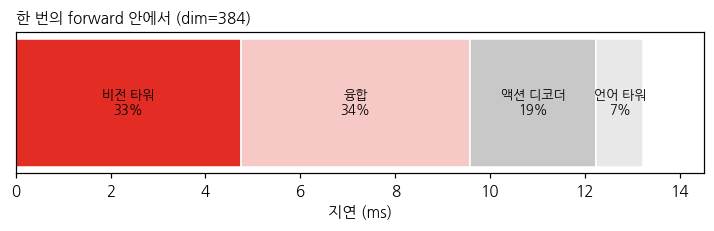

In [3]:
DIM = 384
torch.manual_seed(0); m = MiniVLA(dim=DIM, heads=8).eval()
im, tk, ac = make_dataset(8, 3); x1, t1 = im[:1], tk[:1]

with torch.no_grad():
    tot = bench(lambda: m(x1, t1))
    t_patch = bench(lambda: m.patch_embed(x1))
    def vis():
        y = m.patch_embed(x1)
        for b in m.vis: y, _ = b(y)
        return y
    t_vis = bench(vis)
    t_lang = bench(lambda: m.lang(t1))
    vv, ll = vis(), m.lang(t1)
    def fuse():
        x = torch.cat([vv + m.modality[0], ll + m.modality[1]], 1)
        for b in m.fuse: x, _ = b(x)
        return m.norm(x)
    t_fuse = bench(fuse)
    xx = fuse()
    def dec():
        q = m.aq.expand(1, -1, -1)
        y, _ = m.dec(torch.cat([xx, q], 1))
        return m.head(y[:, -m.adim:])
    t_dec = bench(dec)

parts = [("비전 타워", t_vis), ("융합", t_fuse), ("액션 디코더", t_dec), ("언어 타워", t_lang)]
print(f"구성요소별 지연 (dim={DIM}, 배치 1)")
for n_, v_ in parts:
    print(f"  {n_:<14} {v_:7.2f} ms   {100*v_/tot:5.1f}%   " + "█" * int(40 * v_ / tot))
print(f"  {'전체 (측정)':<14} {tot:7.2f} ms   → {1000/tot:.1f} Hz")
print(f"  (참고) 패치 임베딩만 {t_patch:.2f} ms — 비전 타워 안에 포함")

fig, ax = plt.subplots(figsize=(6.6, 2.2))
left = 0
for (n_, v_), c in zip(parts, [RED, PINK, GREY, "#e8e8e8"]):
    ax.barh([0], [v_], left=left, color=c, edgecolor="white")
    if v_ / tot > .07:
        ax.text(left + v_/2, 0, f"{n_}\n{100*v_/tot:.0f}%", ha="center", va="center", fontsize=8.5)
    left += v_
ax.set_yticks([]); ax.set_xlabel("지연 (ms)"); ax.set_xlim(0, tot * 1.02)
ax.set_title(f"한 번의 forward 안에서 (dim={DIM})", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 3. 토큰 수가 지연을 지배한다

이미지를 키우면 패치가 늘고, 패치가 늘면 토큰이 는다. 48×48·패치 8 이면 36 토큰이고, 128×128 이면 256 토큰이다.

  이미지             토큰     지연 ms     달성 Hz
  --------------------------------------


  32x32           16     12.79      78.2


  48x48           36     14.45      69.2


  64x64           64     13.60      73.5


  96x96          144     21.22      47.1


  128x128        256     33.83      29.6


  160x160        400     54.43      18.4

  직선 맞춤:  지연 ≈ 8.5 ms + 0.108 ms × 토큰수
  고정 비용이 59% (48x48 기준)


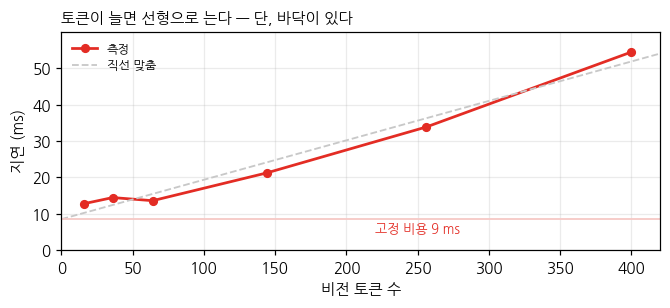

In [4]:
imgs = [32, 48, 64, 96, 128, 160]
toks, lats = [], []
print(f"  {'이미지':<12}{'토큰':>6}{'지연 ms':>10}{'달성 Hz':>10}")
print("  " + "-" * 38)
for img in imgs:
    torch.manual_seed(0); mm = MiniVLA(dim=DIM, heads=8, img=img).eval()
    x = torch.randn(1, 3, img, img); t = torch.zeros(1, 5, dtype=torch.long)
    with torch.no_grad(): ms = bench(lambda: mm(x, t))
    toks.append((img // 8) ** 2); lats.append(ms)
    print(f"  {f'{img}x{img}':<12}{toks[-1]:>6}{ms:>10.2f}{1000/ms:>10.1f}")

slope, intercept = np.polyfit(toks, lats, 1)
print(f"\n  직선 맞춤:  지연 ≈ {intercept:.1f} ms + {slope:.3f} ms × 토큰수")
print(f"  고정 비용이 {100*intercept/lats[1]:.0f}% (48x48 기준)")

fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.plot(toks, lats, "o-", color=RED, lw=1.8, ms=5, label="측정")
xs = np.array([0, max(toks) * 1.05])
ax.plot(xs, intercept + slope * xs, "--", color=GREY, lw=1.2, label="직선 맞춤")
ax.axhline(intercept, color=PINK, lw=1.2)
ax.text(max(toks) * .55, intercept * .55, f"고정 비용 {intercept:.0f} ms", fontsize=8.5, color=RED)
ax.set_xlabel("비전 토큰 수"); ax.set_ylabel("지연 (ms)")
ax.set_xlim(0, max(toks) * 1.05); ax.set_ylim(0, max(lats) * 1.1)
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("토큰이 늘면 선형으로 는다 — 단, 바닥이 있다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 4. 양자화 — 정확도는 공짜, 속도는 조건부

가중치를 INT8 로 낮춘다. PyTorch 의 동적 양자화는 선형 계층의 가중치를 INT8 로 저장하고 활성값은 실행 중에 양자화한다.

먼저 **정확도** 부터 본다. 13장에서 학습해 둔 모델을 그대로 쓴다(없으면 이 자리에서 짧게 학습한다).

In [5]:
from mini_vla import make_dataset as _md
Dtr = _md(4096, 0); Dte = _md(512, 99)

def fit(model, D, steps=900, lr=1.5e-3, bs=48):
    torch.manual_seed(0); im, tk, ac = D
    opt = torch.optim.AdamW(model.parameters(), lr, weight_decay=.01)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(im), (bs,), generator=g)
        loss = F.smooth_l1_loss(model(im[idx], tk[idx]), ac[idx], beta=.05)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return model

t0 = time.time()
torch.manual_seed(0); base = fit(MiniVLA(), Dtr).eval()
print(f"학습 {time.time()-t0:.0f}s")

@torch.no_grad()
def score(mm, D):
    im, tk, ac = D; p = mm(im, tk)
    a = torch.atan2(p[:, 1], p[:, 0]); b = torch.atan2(ac[:, 1], ac[:, 0])
    ang = torch.abs(torch.rad2deg(torch.atan2(torch.sin(a-b), torch.cos(a-b)))).mean().item()
    return F.l1_loss(p, ac).item(), ang

def ckpt_kb(mm):
    b = io.BytesIO(); torch.save(mm.state_dict(), b); return b.getbuffer().nbytes / 1024

qbase = torch.ao.quantization.quantize_dynamic(base, {nn.Linear}, dtype=torch.qint8).eval()
print(f"\n{'':8}{'MAE':>9}{'각도':>9}{'체크포인트':>12}")
for tag, mm in [("fp32", base), ("int8", qbase)]:
    mae, ang = score(mm, Dte)
    print(f"  {tag:<6}{mae:>9.4f}{ang:>8.2f}°{ckpt_kb(mm):>10.0f} KB")
with torch.no_grad():
    d = (base(Dte[0], Dte[1]) - qbase(Dte[0], Dte[1])).abs()
print(f"\n  두 모델의 출력 차이: 평균 {d.mean():.5f}  최대 {d.max():.5f}   (액션 범위 ±1)")

학습 109s

              MAE       각도       체크포인트


  fp32     0.0263    4.24°      2967 KB


  int8     0.0282    4.35°      1626 KB



  두 모델의 출력 차이: 평균 0.00568  최대 0.05253   (액션 범위 ±1)


  dim             파라미터   fp32 ms   int8 ms      배율
  --------------------------------------------------


  96           748,897      3.71      4.04   0.92x


  192        2,935,489      5.43      5.01   1.08x


  384       11,621,761     14.28      9.35   1.53x


  768       46,246,657     30.79     19.40   1.59x


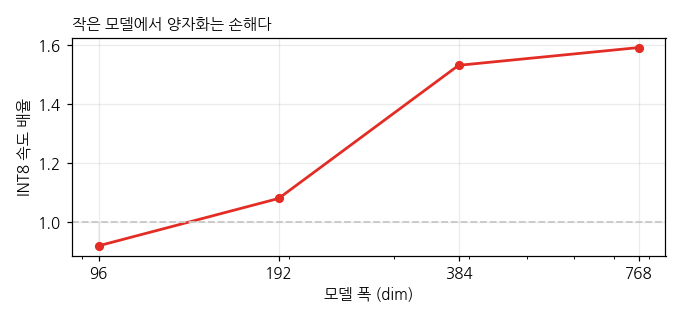

In [6]:
dims = [96, 192, 384, 768]
sp, pars, f32s, i8s = [], [], [], []
print(f"  {'dim':<8}{'파라미터':>12}{'fp32 ms':>10}{'int8 ms':>10}{'배율':>8}")
print("  " + "-" * 50)
for dim in dims:
    torch.manual_seed(0); mm = MiniVLA(dim=dim, heads=max(4, dim // 48)).eval()
    p = sum(x.numel() for x in mm.parameters())
    with torch.no_grad():
        a = bench(lambda: mm(x1, t1))
        q = torch.ao.quantization.quantize_dynamic(mm, {nn.Linear}, dtype=torch.qint8).eval()
        b = bench(lambda: q(x1, t1))
    pars.append(p); f32s.append(a); i8s.append(b); sp.append(a / b)
    print(f"  {dim:<8}{p:>12,}{a:>10.2f}{b:>10.2f}{a/b:>7.2f}x")

fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.plot(dims, sp, "o-", color=RED, lw=1.8, ms=5)
ax.axhline(1.0, color=GREY, ls="--", lw=1.2)
ax.fill_between(dims, 1.0, sp, where=[s < 1 for s in sp], color=GREY, alpha=.3)
ax.set_xscale("log"); ax.set_xticks(dims)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())     # 로그축 보조 눈금 라벨 제거
ax.set_xlabel("모델 폭 (dim)"); ax.set_ylabel("INT8 속도 배율")
ax.grid(alpha=.25); ax.set_title("작은 모델에서 양자화는 손해다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 5. 컴파일 — 양자화와 정반대로 작동한다

`torch.compile` 은 그래프를 추적해 커널을 융합하고 파이썬 호출 오버헤드를 줄인다. 3절에서 고정 비용이 59% 라고 했으니 바로 이 도구가 노릴 자리로 보인다. 재 보자.

In [7]:
print(f"  {'dim':<8}{'eager ms':>11}{'compile ms':>12}{'배율':>8}")
print("  " + "-" * 40)
for d in (96, 384):
    torch.manual_seed(0); mm = MiniVLA(dim=d, heads=max(4, d // 48)).eval()
    with torch.no_grad():
        a = bench(lambda: mm(x1, t1))
        try:
            cm = torch.compile(mm)
            b = bench(lambda: cm(x1, t1), n=20, warm=40, reps=5)
            print(f"  {d:<8}{a:>11.2f}{b:>12.2f}{a/b:>7.2f}x")
        except Exception as e:
            print(f"  {d:<8}  컴파일 실패: {str(e)[:50]}")

  dim        eager ms  compile ms      배율
  ----------------------------------------


  96             3.28        1.98   1.65x


  384           13.76       13.67   1.01x


## 6. 청크로 제어 주파수를 사들인다

추론을 빠르게 만드는 대신 **덜 자주 하는** 길이 있다. 7장에서 본 액션 청킹이다. 한 번 추론해 K 스텝의 액션을 받으면 제어 주파수는 추론 주파수의 K 배가 된다.

<!-- LaTeX: f_{\text{control}} = K \cdot f_{\text{infer}} = \frac{1000\,K}{t_{\text{infer}}}\ \text{Hz} -->

공짜는 아니다. 청크의 뒷부분은 **K 스텝 전의 관측**으로 만든 액션이므로 그만큼 오래된 정보다.

추론 지연 14.5 ms 일 때
  청크 K           추론 Hz     제어 Hz         청크 끝의 관측 나이
  ----------------------------------------------------
  1               69.2      69.2             14.5 ms
  2               69.2     138.4             21.7 ms
  4               69.2     276.7             25.3 ms
  8               69.2     553.5             27.1 ms
  16              69.2    1107.0             28.0 ms
  32              69.2    2213.9             28.5 ms


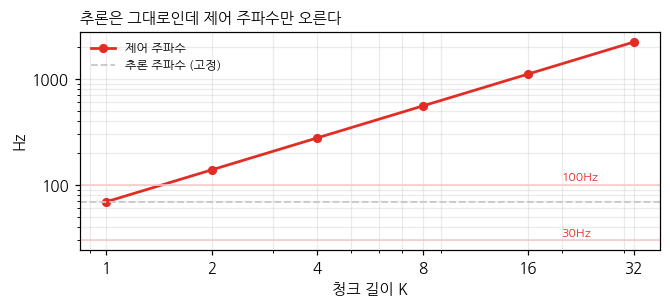

In [8]:
L = lats[1]                     # 48x48 실측 지연
print(f"추론 지연 {L:.1f} ms 일 때")
print(f"  {'청크 K':<10}{'추론 Hz':>10}{'제어 Hz':>10}{'청크 끝의 관측 나이':>20}")
print("  " + "-" * 52)
Ks = [1, 2, 4, 8, 16, 32]
ctrl = []
for K in Ks:
    f_inf = 1000 / L; f_ctl = f_inf * K
    age = (K - 1) / f_ctl * 1000 + L
    ctrl.append(f_ctl)
    print(f"  {K:<10}{f_inf:>10.1f}{f_ctl:>10.1f}{age:>17.1f} ms")

fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.plot(Ks, ctrl, "o-", color=RED, lw=1.8, ms=5, label="제어 주파수")
ax.axhline(1000 / L, color=GREY, ls="--", lw=1.2, label="추론 주파수 (고정)")
for tgt, lbl in [(30, "30Hz"), (100, "100Hz")]:
    ax.axhline(tgt, color=PINK, lw=1.0)
    ax.text(Ks[-1] * .62, tgt * 1.08, lbl, fontsize=8, color=RED)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xticks(Ks)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("청크 길이 K"); ax.set_ylabel("Hz")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25, which="both")
ax.set_title("추론은 그대로인데 제어 주파수만 오른다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 7. 예산표 만들기

지금까지 잰 것을 하나의 표로 합친다. 목표 주파수를 정하면 그 예산 안에 무엇이 들어가는지, 어떤 조합이 가능한지가 나온다.

In [9]:
CAPTURE, POST = 16.0, 0.01                     # 30fps 카메라 평균 대기
PRE = bench(prep, 200, 50)                     # 전처리는 위에서 잰 값을 그대로
def budget(t_infer, K, target_hz):
    cycle = 1000 / target_hz
    per_infer = CAPTURE + PRE + t_infer + POST
    used = per_infer / K                         # K 스텝에 걸쳐 상각
    return used, cycle, used <= cycle

print(f"카메라 {CAPTURE:.1f}ms + 전처리 {PRE:.2f}ms + 추론 t + 후처리 {POST}ms, K 스텝 상각")
print(f"\n  {'구성':<34}{'사이클당':>10}{'30Hz':>8}{'50Hz':>8}{'100Hz':>8}")
print("  " + "-" * 68)
cfgs = [("48px, K=1", lats[1], 1), ("48px, K=2", lats[1], 2),
        ("48px, K=4", lats[1], 4), ("160px, K=1", lats[5], 1),
        ("160px, K=4", lats[5], 4), ("160px, K=8", lats[5], 8)]
for name, ti, K in cfgs:
    used, _, _ = budget(ti, K, 30)
    marks = "".join(f"{'  OK' if budget(ti, K, hz)[2] else '  --':>8}" for hz in (30, 50, 100))
    print(f"  {name:<34}{used:>9.1f}ms{marks}")

print("\n  카메라 대기를 뺀다면 (트리거 동기화 / 글로벌 셔터)")
CAPTURE = 0.0
for name, ti, K in cfgs:
    used, _, _ = budget(ti, K, 30)
    marks = "".join(f"{'  OK' if budget(ti, K, hz)[2] else '  --':>8}" for hz in (30, 50, 100))
    print(f"  {name:<34}{used:>9.1f}ms{marks}")

카메라 16.0ms + 전처리 0.16ms + 추론 t + 후처리 0.01ms, K 스텝 상각

  구성                                      사이클당    30Hz    50Hz   100Hz
  --------------------------------------------------------------------
  48px, K=1                              30.6ms      OK      --      --
  48px, K=2                              15.3ms      OK      OK      --
  48px, K=4                               7.7ms      OK      OK      OK
  160px, K=1                             70.6ms      --      --      --
  160px, K=4                             17.7ms      OK      OK      --
  160px, K=8                              8.8ms      OK      OK      OK

  카메라 대기를 뺀다면 (트리거 동기화 / 글로벌 셔터)
  48px, K=1                              14.6ms      OK      OK      --
  48px, K=2                               7.3ms      OK      OK      OK
  48px, K=4                               3.7ms      OK      OK      OK
  160px, K=1                             54.6ms      --      --      --
  160px, K=4                             13.7ms   

### 다음 장으로

다음 장에서는 이 정책을 실제 로봇 루프에 끼워 넣는다. 10Hz 로 도는 정책과 1kHz 로 도는 컨트롤러를 어떻게 잇고, 지연이 흔들릴 때 무엇이 무너지며, 안전을 어디서 강제할 것인가가 남았다.